# Total games per match â€” best-of-3, by surface

Distribution of the number of games in completed ATP best-of-3 matches, from
`atp/data/atp.db`.

**Counting convention:** each set contributes the sum of its game scores; a tiebreak
set counts as one game for the winner â€” a 7-6 set is **13 games** regardless of
tiebreak points. (This matches how Kalshi's KXATPGTOTAL markets count games.)

**Filters:**
- completed matches only (`reason IS NULL` â€” no retirements, walkovers, defaults)
- best-of-3 formats only: Grand Slams excluded (bo5); Laver Cup and Next Gen Finals
  excluded (non-standard set formats)
- sanity bound 12â€“39 games (a valid bo3 range: 12 = 6-0 6-0, 39 = three 13-game sets)

In [1]:
import sqlite3
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# fixed CVD-safe surface colors (Okabe-Ito)
SURF_COLOR = {"Hard": "#0072B2", "Clay": "#D55E00", "Grass": "#009E73"}
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
                     "axes.spines.top": False, "axes.spines.right": False})

ROOT = Path.cwd()
while not (ROOT / "atp").exists():
    ROOT = ROOT.parent
db = sqlite3.connect(f"file:{(ROOT / 'atp/data/atp.db').as_posix()}?mode=ro", uri=True)

df = pd.read_sql("""
    SELECT m.p1_score, m.p2_score, m.surface, m.year, t.tourney_type
    FROM matches m JOIN tournaments t USING (tourney_year_id)
    WHERE m.reason IS NULL
      AND t.tourney_type NOT IN ('Grand Slam', 'Laver Cup', 'Next Gen Finals')
""", db)
print(f"{len(df):,} completed bo3-format matches loaded")
df.head(3)

7,181 completed bo3-format matches loaded


,p1_score,p2_score,surface,year,tourney_type
0,7;6,6;4,Hard,2024,ATP 250
1,6;7,4;6,Hard,2024,ATP 250
2,6;7,3;5,Hard,2024,ATP 250


In [2]:
def total_games(row):
    a = [int(x) for x in row.p1_score.split(";")]
    b = [int(x) for x in row.p2_score.split(";")]
    return sum(a) + sum(b)      # 7-6 set contributes 13 automatically

df["games"] = df.apply(total_games, axis=1)
n0 = len(df)
df = df[df.games.between(12, 39)]
df = df[df.surface.isin(SURF_COLOR)]
print(f"dropped {n0 - len(df)} rows outside the valid bo3 range / unknown surface")
print(f"final sample: {len(df):,} matches "
      f"({', '.join(f'{s}: {n:,}' for s, n in df.surface.value_counts().items())})")

dropped 0 rows outside the valid bo3 range / unknown surface
final sample: 7,181 matches (Hard: 3,866, Clay: 2,622, Grass: 693)


## Overall distribution

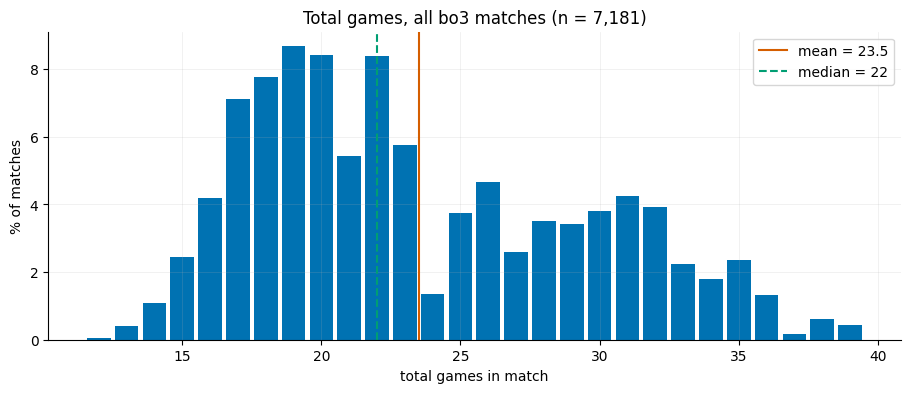

count    7181.00
mean       23.50
std         5.95
min        12.00
25%        19.00
50%        22.00
75%        28.00
max        39.00
Name: games, dtype: float64

In [3]:
counts = df.games.value_counts(normalize=True).sort_index()
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(counts.index, counts.values * 100, color="#0072B2", width=0.85)
ax.axvline(df.games.mean(), color="#D55E00", lw=1.5,
           label=f"mean = {df.games.mean():.1f}")
ax.axvline(df.games.median(), color="#009E73", lw=1.5, ls="--",
           label=f"median = {df.games.median():.0f}")
ax.set_xlabel("total games in match")
ax.set_ylabel("% of matches")
ax.set_title(f"Total games, all bo3 matches (n = {len(df):,})")
ax.legend()
plt.show()
df.games.describe().round(2)

Note the bimodal shape: straight-sets matches cluster around 18â€“22 games,
three-setters around 28â€“32 â€” there is a visible valley between the two regimes.

## Distribution by surface

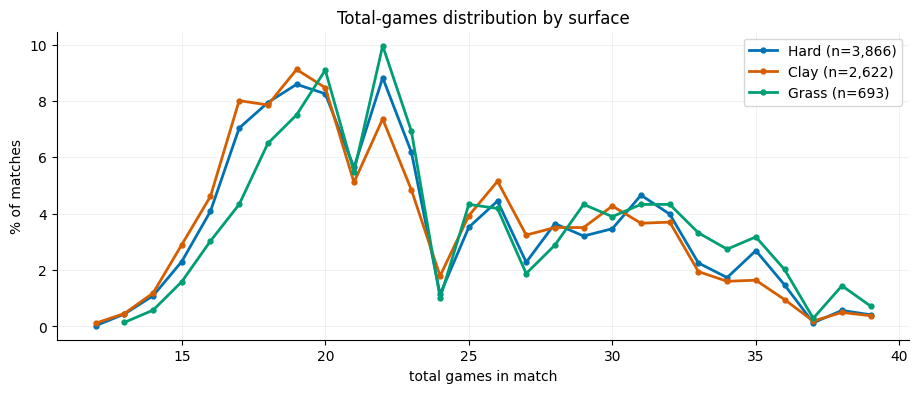

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
for surf, color in SURF_COLOR.items():
    g = df[df.surface == surf].games
    pct = g.value_counts(normalize=True).sort_index() * 100
    ax.plot(pct.index, pct.values, color=color, lw=2, marker="o", ms=3.5,
            label=f"{surf} (n={len(g):,})")
ax.set_xlabel("total games in match")
ax.set_ylabel("% of matches")
ax.set_title("Total-games distribution by surface")
ax.legend()
plt.show()

In [5]:
summary = df.groupby("surface").games.agg(
    n="size", mean="mean", median="median", std="std",
    p10=lambda s: s.quantile(0.10), p25=lambda s: s.quantile(0.25),
    p75=lambda s: s.quantile(0.75), p90=lambda s: s.quantile(0.90))
summary.round(2)

,n,mean,median,std,p10,p25,p75,p90
surface,,,,,,,,
Clay,2622,23.16,22.0,5.84,17.0,18.0,28.0,32.0
Grass,693,24.59,23.0,6.15,18.0,20.0,30.0,34.0
Hard,3866,23.53,22.0,5.97,17.0,19.0,28.0,32.0


## P(total games > K) by surface

The strike ladder Kalshi actually lists (K + 0.5 thresholds) â€” directly comparable
to KXATPGTOTAL prices.

In [6]:
strikes = np.arange(14.5, 32, 1.0)
rows = {}
for surf in SURF_COLOR:
    g = df[df.surface == surf].games
    rows[surf] = {k: (g > k).mean() for k in strikes}
rows["All"] = {k: (df.games > k).mean() for k in strikes}
pover = pd.DataFrame(rows).round(3)
pover.index.name = "over K"
pover

,Hard,Clay,Grass,All
over K,,,,
14.5,0.984,0.982,0.993,0.985
15.5,0.961,0.953,0.977,0.960
16.5,0.921,0.907,0.947,0.918
17.5,0.850,0.827,0.903,0.847
18.5,0.771,0.749,0.838,0.769
19.5,0.685,0.658,0.763,0.682
20.5,0.602,0.573,0.672,0.598
21.5,0.546,0.522,0.618,0.544
22.5,0.458,0.448,0.518,0.460


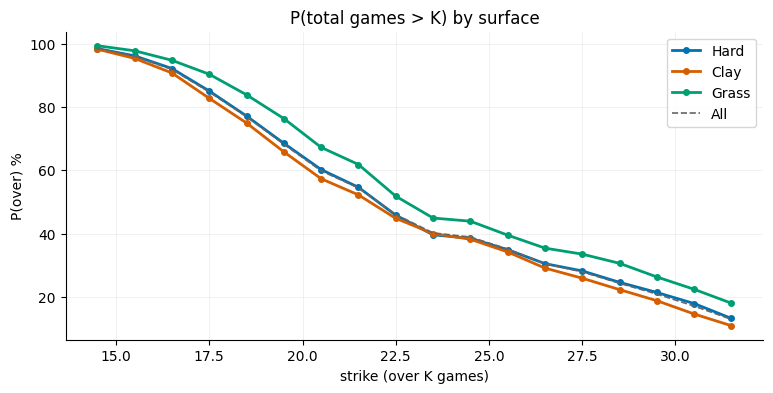

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
for surf, color in SURF_COLOR.items():
    ax.plot(pover.index, pover[surf] * 100, color=color, lw=2, marker="o", ms=4,
            label=surf)
ax.plot(pover.index, pover["All"] * 100, color="#666666", lw=1.2, ls="--", label="All")
ax.set_xlabel("strike (over K games)")
ax.set_ylabel("P(over) %")
ax.set_title("P(total games > K) by surface")
ax.legend()
plt.show()

## Read-out

- Grass runs longest (serve-dominated: fewer breaks, more 7-6/13-game sets),
  clay shortest, hard in between â€” the gap at the typical middle strike (22.5)
  is worth several cents of probability.
- Use the P(over K) table as the empirical anchor when sanity-checking model or
  market prices for KXATPGTOTAL strikes.

## Conditioning on the skill gap (ATP ranking points at match date)

Total games depend on *closeness*: even matchups produce deciding sets, mismatches
produce routs. Skill gap proxy: absolute difference in **rolling ATP points** at the
most recent weekly `rank_date` on or before the match date. Buckets follow the upset
study: 0–500, 500–1k, 1k–2k, 2k–5k, 5k+.

In [8]:
dm = pd.read_sql("""
    SELECT m.p1_id, m.p2_id, m.match_date, m.p1_score, m.p2_score, m.surface
    FROM matches m JOIN tournaments t USING (tourney_year_id)
    WHERE m.reason IS NULL
      AND t.tourney_type NOT IN ('Grand Slam', 'Laver Cup', 'Next Gen Finals')
      AND m.match_date IS NOT NULL
""", db)
dm["games"] = dm.apply(total_games, axis=1)
dm = dm[dm.games.between(12, 39) & dm.surface.isin(SURF_COLOR)]
dm["match_date"] = pd.to_datetime(dm.match_date)

rk = pd.read_sql("SELECT player_id, rank_date, roll_points FROM player_rankings", db)
rk["rank_date"] = pd.to_datetime(rk.rank_date)
rk = rk.dropna(subset=["roll_points"]).sort_values("rank_date")

def asof_points(df, id_col, out_col):
    left = df[[id_col, "match_date"]].reset_index()
    left = left.sort_values("match_date")
    j = pd.merge_asof(left, rk.rename(columns={"player_id": id_col,
                                               "roll_points": out_col}),
                      left_on="match_date", right_on="rank_date",
                      by=id_col, direction="backward",
                      tolerance=pd.Timedelta("60D"))
    return j.set_index("index")[out_col]

dm["pts1"] = asof_points(dm, "p1_id", "pts1")
dm["pts2"] = asof_points(dm, "p2_id", "pts2")
n0 = len(dm)
dm = dm.dropna(subset=["pts1", "pts2"])
dm["gap"] = (dm.pts1 - dm.pts2).abs()
print(f"{len(dm):,} matches with both players' rankings ({n0 - len(dm)} dropped)")

6,504 matches with both players' rankings (0 dropped)


In [9]:
edges = [0, 500, 1000, 2000, 5000, np.inf]
labels = ["0-500", "500-1k", "1k-2k", "2k-5k", "5k+"]
dm["gap_bucket"] = pd.cut(dm.gap, edges, labels=labels)

tbl = dm.groupby("gap_bucket", observed=True).games.agg(
    n="size", mean="mean", median="median",
    p_over_205=lambda s: (s > 20.5).mean(),
    p_over_225=lambda s: (s > 22.5).mean(),
    p_over_245=lambda s: (s > 24.5).mean())
tbl.round(3)

,n,mean,median,p_over_205,p_over_225,p_over_245
gap_bucket,,,,,,
0-500,3388,23.584,22.0,0.606,0.468,0.401
500-1k,1185,23.730,22.0,0.614,0.487,0.402
1k-2k,912,23.567,22.0,0.596,0.454,0.380
2k-5k,759,23.739,22.0,0.623,0.470,0.391
5k+,257,21.922,20.0,0.498,0.339,0.272


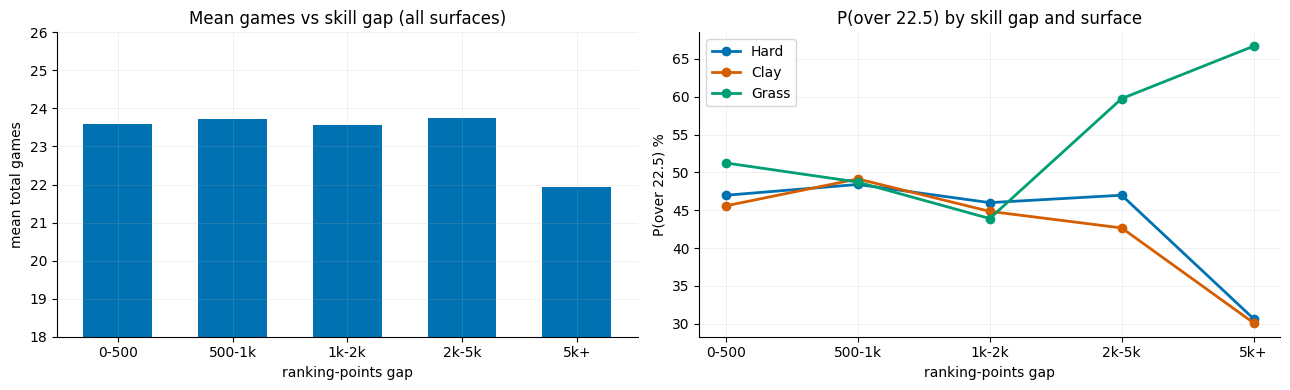

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(len(labels))

means = dm.groupby("gap_bucket", observed=True).games.mean()
axes[0].bar(x, means.values, color="#0072B2", width=0.6)
axes[0].set_xticks(x, labels)
axes[0].set_xlabel("ranking-points gap")
axes[0].set_ylabel("mean total games")
axes[0].set_title("Mean games vs skill gap (all surfaces)")
axes[0].set_ylim(18, 26)

for surf, color in SURF_COLOR.items():
    p = dm[dm.surface == surf].groupby("gap_bucket", observed=True).games \
          .apply(lambda s: (s > 22.5).mean())
    axes[1].plot(x, p.values * 100, color=color, lw=2, marker="o", label=surf)
axes[1].set_xticks(x, labels)
axes[1].set_xlabel("ranking-points gap")
axes[1].set_ylabel("P(over 22.5) %")
axes[1].set_title("P(over 22.5) by skill gap and surface")
axes[1].legend()
plt.tight_layout()
plt.show()

In [11]:
pivot = dm.pivot_table(index="gap_bucket", columns="surface", values="games",
                       aggfunc="mean", observed=True)
pivot["n"] = dm.groupby("gap_bucket", observed=True).size()
pivot.round(2)

surface,Clay,Grass,Hard,n
gap_bucket,,,,
0-500,23.37,24.57,23.57,3388
500-1k,23.40,24.01,23.87,1185
1k-2k,23.17,24.41,23.69,912
2k-5k,22.93,25.25,23.87,759
5k+,21.47,25.79,21.55,257


### Read-out (surprising)

- **Ranking-points gap barely moves totals** — mean games and P(over 22.5) are flat
  across all buckets up to 5k points. Only the extreme 5k+ bucket (n=257, ~4% of
  matches) shortens matches: −1.7 mean games, P(over 22.5) drops 0.47 → 0.34.
- Interpretation: serve dominance keeps game counts close even between mismatched
  players — holding serve is much easier than winning a match. Ranking gap predicts
  *who wins* far better than *how long it takes*.
- Surface matters more than ranking gap for totals (grass−clay ≈ 6pts of P(over 22.5)
  at every gap level; grass stays long even in 5k+ mismatches — 25.8 mean games).
- **Trading implication:** the pre-match closeness proxy adds little for totals
  except as a 5k+ mismatch flag; the live match price (which prices *today's* form
  and in-match state) remains the right closeness input for the fair-value engine.
